<a href="https://colab.research.google.com/github/aniket-alt/CMPE-258-Deep-Learning/blob/main/Assignment%20-%204/4_advanced_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4: Advanced PyTorch Deep Learning Customizations
## Building Custom Components from Scratch in PyTorch

---

**Author:** Aniket Patole  
**Course:** CMPE 258 - Deep Learning  
**Assignment:** Advanced Customizations in Deep Learning and Neural Networks

---

### Objective

This notebook demonstrates how to build custom components in PyTorch, giving you complete control over your deep learning models. We'll implement:

1. **Custom Learning Rate Schedulers** - OneCycleLR and Warmup schedulers
2. **Custom Dropout Layers** - MC Dropout and Alpha Dropout
3. **Custom Normalization** - Layer Normalization from scratch
4. **Custom Loss Functions** - Huber Loss, Focal Loss
5. **Custom Activation Functions** - Swish, Mish, parametric activations
6. **Custom Weight Initialization** - Xavier, Kaiming, Orthogonal
7. **Custom Layers** - Dense, Residual blocks, Attention
8. **Custom Models** - ResNet-style architectures
9. **Custom Optimizers** - SGD with Momentum from scratch
10. **TensorBoard Integration** - Training visualization

### PyTorch vs Keras

PyTorch offers more explicit control compared to Keras:
- **Explicit forward pass**: You define exactly how data flows
- **Dynamic computation graphs**: Built on-the-fly during execution
- **Pythonic**: Feels like native Python code
- **Flexible**: Easy to customize every aspect

---

## Part A: Setup and Imports

We import PyTorch and supporting libraries. PyTorch's modular design makes it easy to build and combine custom components.

In [ ]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import _LRScheduler
from torch.utils.tensorboard import SummaryWriter

# For datasets
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchvision import datasets, transforms

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Device: cuda
CUDA Available: True
GPU: Tesla T4


### Loading Datasets

We load two datasets:
1. **California Housing** - For regression tasks
2. **Fashion-MNIST** - For classification tasks

We create PyTorch DataLoaders for efficient batching.

In [ ]:
# Load California Housing dataset for regression
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

# Split and scale
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)
X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(
    X_train_h, y_train_h, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_h = scaler.fit_transform(X_train_h)
X_val_h = scaler.transform(X_val_h)
X_test_h = scaler.transform(X_test_h)

# Convert to PyTorch tensors
X_train_h_t = torch.FloatTensor(X_train_h)
y_train_h_t = torch.FloatTensor(y_train_h).unsqueeze(1)
X_val_h_t = torch.FloatTensor(X_val_h)
y_val_h_t = torch.FloatTensor(y_val_h).unsqueeze(1)
X_test_h_t = torch.FloatTensor(X_test_h)
y_test_h_t = torch.FloatTensor(y_test_h).unsqueeze(1)

# Create DataLoaders for housing
train_housing_ds = TensorDataset(X_train_h_t, y_train_h_t)
val_housing_ds = TensorDataset(X_val_h_t, y_val_h_t)
test_housing_ds = TensorDataset(X_test_h_t, y_test_h_t)

train_housing_loader = DataLoader(train_housing_ds, batch_size=64, shuffle=True)
val_housing_loader = DataLoader(val_housing_ds, batch_size=64, shuffle=False)
test_housing_loader = DataLoader(test_housing_ds, batch_size=64, shuffle=False)

print("California Housing Dataset (Regression):")
print(f"  Training: {X_train_h_t.shape}, Validation: {X_val_h_t.shape}, Test: {X_test_h_t.shape}")

# Load Fashion-MNIST for classification
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 784
])

train_fashion = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_fashion = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split training into train and validation
train_fashion_ds, val_fashion_ds = torch.utils.data.random_split(
    train_fashion, [50000, 10000], generator=torch.Generator().manual_seed(42)
)

train_fashion_loader = DataLoader(train_fashion_ds, batch_size=128, shuffle=True)
val_fashion_loader = DataLoader(val_fashion_ds, batch_size=128, shuffle=False)
test_fashion_loader = DataLoader(test_fashion, batch_size=128, shuffle=False)

print("\nFashion-MNIST Dataset (Classification):")
print(f"  Training: {len(train_fashion_ds)}, Validation: {len(val_fashion_ds)}, Test: {len(test_fashion)}")

California Housing Dataset (Regression):
  Training: torch.Size([13209, 8]), Validation: torch.Size([3303, 8]), Test: torch.Size([4128, 8])


100%|██████████| 26.4M/26.4M [00:03<00:00, 8.68MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 138kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.9MB/s]


Fashion-MNIST Dataset (Classification):
  Training: 50000, Validation: 10000, Test: 10000


---

# Section 1: Custom Learning Rate Schedulers

## Concept

PyTorch provides a base `_LRScheduler` class that we can extend to create custom schedules. Learning rate scheduling is crucial for achieving optimal convergence.

We'll implement:
1. **OneCycleLR** - The 1cycle policy for super-convergence
2. **WarmupCosineScheduler** - Warmup followed by cosine decay

---

### 1.1 Custom OneCycle Learning Rate Scheduler

The OneCycle policy starts low, increases to max, then decreases to very low. This helps the model explore the loss landscape broadly, then fine-tune.

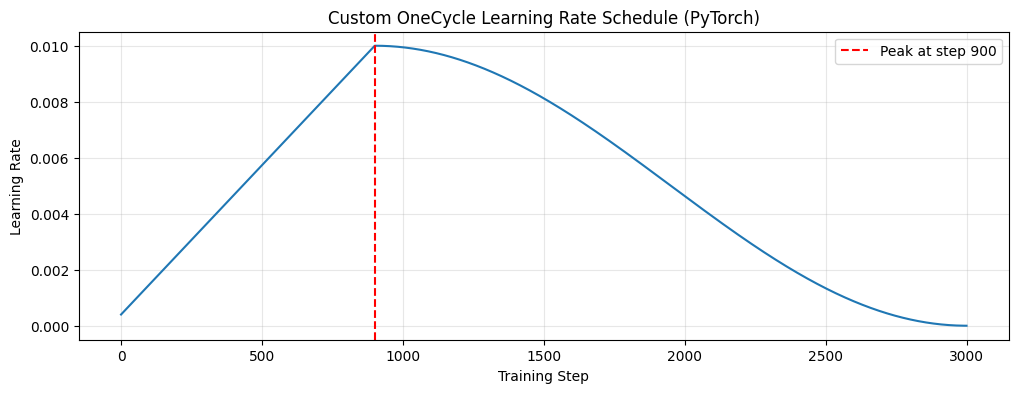

Initial LR: 0.000400
Max LR: 0.010000
Final LR: 0.0000000400


In [ ]:
class OneCycleLR(_LRScheduler):
    """
    Custom OneCycle Learning Rate Scheduler.

    Implements the 1cycle policy:
    - Phase 1: LR increases from initial_lr to max_lr (linear)
    - Phase 2: LR decreases from max_lr to min_lr (cosine)

    Args:
        optimizer: PyTorch optimizer
        max_lr: Maximum learning rate
        total_steps: Total number of training steps
        pct_start: Percentage of steps for increasing phase
        div_factor: initial_lr = max_lr / div_factor
        final_div_factor: min_lr = initial_lr / final_div_factor
    """

    def __init__(self, optimizer, max_lr, total_steps, pct_start=0.3,
                 div_factor=25.0, final_div_factor=1e4, last_epoch=-1):
        self.max_lr = max_lr
        self.total_steps = total_steps
        self.pct_start = pct_start
        self.div_factor = div_factor
        self.final_div_factor = final_div_factor

        self.initial_lr = max_lr / div_factor
        self.min_lr = self.initial_lr / final_div_factor
        self.step_up = int(total_steps * pct_start)

        super(OneCycleLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        """Calculate learning rate for current step."""
        step = self.last_epoch

        if step < self.step_up:
            # Phase 1: Linear increase
            lr = self.initial_lr + (self.max_lr - self.initial_lr) * (step / self.step_up)
        else:
            # Phase 2: Cosine annealing
            progress = (step - self.step_up) / (self.total_steps - self.step_up)
            lr = self.min_lr + (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress)) / 2

        return [lr for _ in self.base_lrs]


# Visualize OneCycle schedule
total_steps = 3000
max_lr = 0.01

# Create dummy optimizer and scheduler
dummy_model = nn.Linear(10, 1)
dummy_optimizer = optim.SGD(dummy_model.parameters(), lr=0.001)
scheduler = OneCycleLR(dummy_optimizer, max_lr=max_lr, total_steps=total_steps)

# Collect learning rates
lrs = []
for step in range(total_steps):
    lrs.append(scheduler.get_lr()[0])
    scheduler.step()

plt.figure(figsize=(12, 4))
plt.plot(lrs)
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('Custom OneCycle Learning Rate Schedule (PyTorch)')
plt.axvline(x=scheduler.step_up, color='r', linestyle='--', label=f'Peak at step {scheduler.step_up}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial LR: {scheduler.initial_lr:.6f}")
print(f"Max LR: {scheduler.max_lr:.6f}")
print(f"Final LR: {scheduler.min_lr:.10f}")

### 1.2 Warmup Cosine Scheduler

A scheduler that linearly warms up the learning rate, then applies cosine annealing. Popular in transformer training.

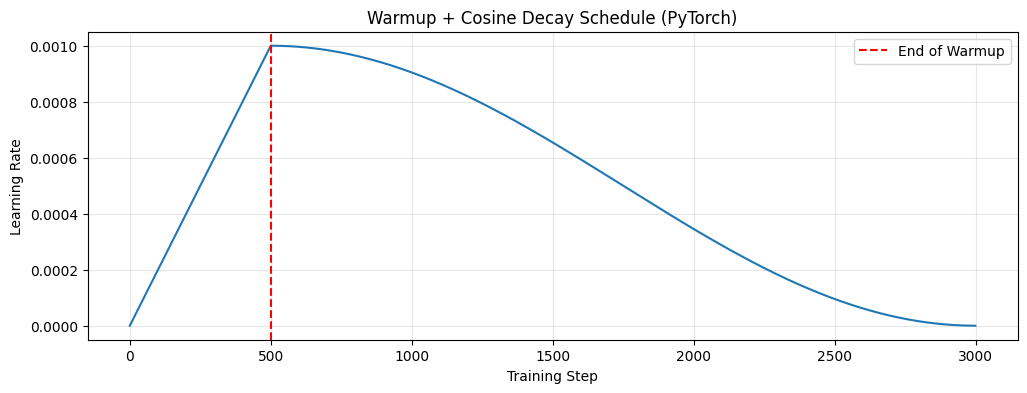

In [ ]:
class WarmupCosineScheduler(_LRScheduler):
    """
    Learning rate scheduler with linear warmup and cosine decay.

    Args:
        optimizer: PyTorch optimizer
        warmup_steps: Number of warmup steps
        total_steps: Total training steps
        min_lr: Minimum learning rate after decay
    """

    def __init__(self, optimizer, warmup_steps, total_steps, min_lr=1e-7, last_epoch=-1):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr = min_lr
        super(WarmupCosineScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        """Calculate learning rate for current step."""
        step = self.last_epoch

        if step < self.warmup_steps:
            # Linear warmup
            scale = step / self.warmup_steps
            return [base_lr * scale for base_lr in self.base_lrs]
        else:
            # Cosine decay
            progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
            return [self.min_lr + (base_lr - self.min_lr) * cosine_decay
                    for base_lr in self.base_lrs]


# Visualize Warmup Cosine schedule
dummy_optimizer2 = optim.SGD(dummy_model.parameters(), lr=0.001)
warmup_scheduler = WarmupCosineScheduler(
    dummy_optimizer2, warmup_steps=500, total_steps=3000
)

lrs_warmup = []
for step in range(3000):
    lrs_warmup.append(warmup_scheduler.get_lr()[0])
    warmup_scheduler.step()

plt.figure(figsize=(12, 4))
plt.plot(lrs_warmup)
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('Warmup + Cosine Decay Schedule (PyTorch)')
plt.axvline(x=500, color='r', linestyle='--', label='End of Warmup')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# Section 2: Custom Dropout Layers

## Concept

We'll implement custom dropout variants:

1. **MC Dropout** - Keeps dropout active during inference for uncertainty estimation
2. **Alpha Dropout** - Maintains self-normalizing property for SELU activation

---

In [ ]:
class MCDropout(nn.Module):
    """
    Monte Carlo Dropout Layer.

    Unlike standard dropout, MC Dropout stays active during inference,
    enabling uncertainty estimation through multiple forward passes.

    Args:
        p: Dropout probability
    """

    def __init__(self, p=0.5):
        super(MCDropout, self).__init__()
        self.p = p

    def forward(self, x):
        # Always apply dropout, regardless of training mode
        return F.dropout(x, p=self.p, training=True)


class AlphaDropout(nn.Module):
    """
    Alpha Dropout for Self-Normalizing Networks (SELU).

    Maintains the self-normalizing property by:
    1. Setting dropped units to the negative saturation value
    2. Applying an affine transformation to preserve mean/variance

    Args:
        p: Dropout probability
    """

    def __init__(self, p=0.5):
        super(AlphaDropout, self).__init__()
        self.p = p
        # SELU parameters
        self.alpha = 1.6732632423543772848170429916717
        self.scale = 1.0507009873554804934193349852946
        self.alpha_p = -self.alpha * self.scale

    def forward(self, x):
        if not self.training:
            return x

        # Calculate affine transformation parameters
        keep_prob = 1.0 - self.p
        a = (keep_prob + keep_prob * (1 - keep_prob) * self.alpha_p ** 2) ** -0.5
        b = -a * self.alpha_p * (1 - keep_prob)

        # Create dropout mask
        mask = torch.bernoulli(torch.full_like(x, keep_prob))

        # Apply alpha dropout
        dropped = x * mask + self.alpha_p * (1 - mask)

        # Apply affine transformation
        return a * dropped + b


# Demonstrate MC Dropout
print("MC Dropout Demonstration")
print("=" * 50)

mc_dropout = MCDropout(p=0.3)
sample_input = torch.tensor([[1.0, 2.0, 3.0, 4.0, 5.0]])

print(f"Input: {sample_input.numpy()}")
print("\nMultiple forward passes (MC Dropout stays active):")
mc_dropout.eval()  # Set to eval mode
for i in range(5):
    output = mc_dropout(sample_input)
    print(f"  Pass {i+1}: {output.numpy().round(3)}")

print("\nEach pass produces different outputs for uncertainty estimation.")

MC Dropout Demonstration
Input: [[1. 2. 3. 4. 5.]]

Multiple forward passes (MC Dropout stays active):
  Pass 1: [[0.    2.857 4.286 5.714 7.143]]
  Pass 2: [[1.429 2.857 4.286 5.714 7.143]]
  Pass 3: [[1.429 2.857 4.286 5.714 0.   ]]
  Pass 4: [[0.    2.857 4.286 0.    7.143]]
  Pass 5: [[1.429 2.857 4.286 0.    7.143]]

Each pass produces different outputs for uncertainty estimation.


---

# Section 3: Custom Loss Functions

## Concept

PyTorch losses can be created by extending `nn.Module`. We'll implement:

1. **Huber Loss** - Robust to outliers
2. **Focal Loss** - For class imbalance
3. **Label Smoothing Cross Entropy** - Regularization technique

---

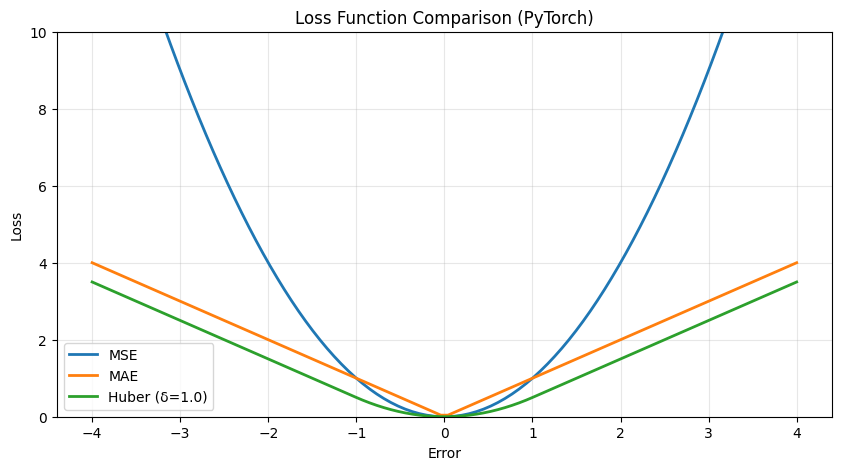

In [ ]:
class HuberLoss(nn.Module):
    """
    Huber Loss - robust to outliers.

    Combines MSE (for small errors) and MAE (for large errors).

    L = 0.5 * x^2                  if |x| <= delta
    L = delta * |x| - 0.5 * delta^2  otherwise

    Args:
        delta: Threshold between quadratic and linear regions
        reduction: 'mean', 'sum', or 'none'
    """

    def __init__(self, delta=1.0, reduction='mean'):
        super(HuberLoss, self).__init__()
        self.delta = delta
        self.reduction = reduction

    def forward(self, y_pred, y_true):
        error = y_true - y_pred
        abs_error = torch.abs(error)

        quadratic = 0.5 * error ** 2
        linear = self.delta * abs_error - 0.5 * self.delta ** 2

        loss = torch.where(abs_error <= self.delta, quadratic, linear)

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance.

    FL(p) = -alpha * (1 - p)^gamma * log(p)

    The (1-p)^gamma factor down-weights easy examples.

    Args:
        alpha: Class weight factor
        gamma: Focusing parameter (higher = more focus on hard examples)
    """

    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Get probabilities
        p = torch.softmax(inputs, dim=1)

        # Get probability of true class
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        p_t = torch.exp(-ce_loss)  # p_t = probability of true class

        # Focal weight
        focal_weight = self.alpha * (1 - p_t) ** self.gamma

        # Focal loss
        focal_loss = focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class LabelSmoothingCrossEntropy(nn.Module):
    """
    Cross Entropy with Label Smoothing.

    Instead of hard labels (0 or 1), uses soft labels:
    - True class: 1 - smoothing
    - Other classes: smoothing / (num_classes - 1)

    This acts as regularization and prevents overconfidence.

    Args:
        smoothing: Label smoothing factor (0.1 is common)
    """

    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing

    def forward(self, inputs, targets):
        n_classes = inputs.size(1)

        # Create smoothed labels
        smooth_labels = torch.full_like(inputs, self.smoothing / (n_classes - 1))
        smooth_labels.scatter_(1, targets.unsqueeze(1), 1 - self.smoothing)

        # Compute cross entropy with smoothed labels
        log_probs = F.log_softmax(inputs, dim=1)
        loss = -(smooth_labels * log_probs).sum(dim=1)

        return loss.mean()


# Visualize Huber Loss vs MSE vs MAE
errors = torch.linspace(-4, 4, 100)
delta = 1.0

mse_losses = errors ** 2
mae_losses = torch.abs(errors)
huber = HuberLoss(delta=delta, reduction='none')
huber_losses = huber(errors, torch.zeros_like(errors))

plt.figure(figsize=(10, 5))
plt.plot(errors.numpy(), mse_losses.numpy(), label='MSE', linewidth=2)
plt.plot(errors.numpy(), mae_losses.numpy(), label='MAE', linewidth=2)
plt.plot(errors.numpy(), huber_losses.detach().numpy(), label=f'Huber (δ={delta})', linewidth=2)
plt.xlabel('Error')
plt.ylabel('Loss')
plt.title('Loss Function Comparison (PyTorch)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 10)
plt.show()

---

# Section 4: Custom Activation Functions

## Concept

Custom activations can be implemented as `nn.Module` or simple functions. We'll implement:

1. **Swish/SiLU** - x * sigmoid(x)
2. **Mish** - x * tanh(softplus(x))
3. **GELU** - Gaussian Error Linear Unit

---

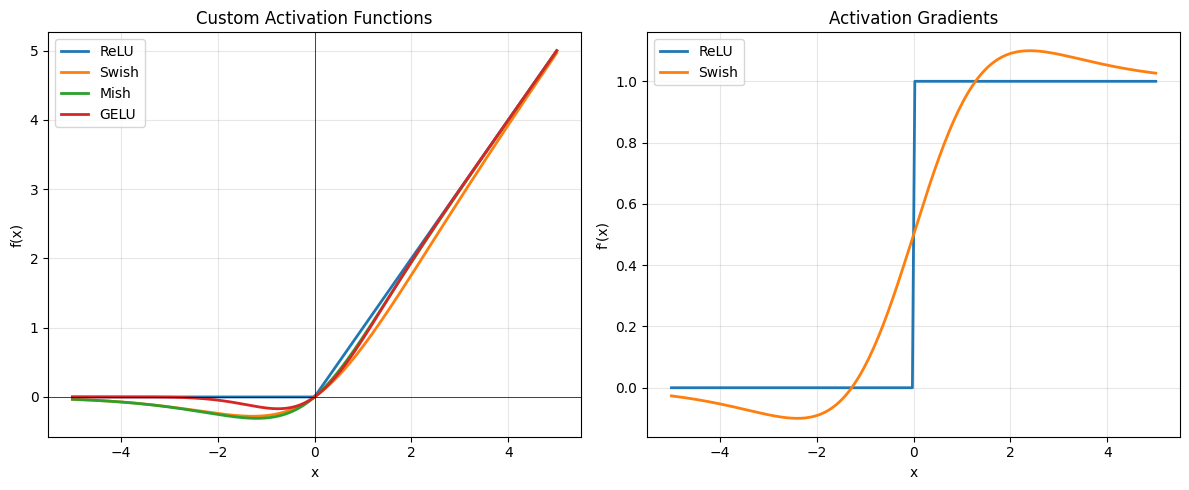

Key observations:
  - ReLU: Simple but 'dead neuron' problem
  - Swish/Mish/GELU: Smooth, allow small negative values


In [ ]:
class Swish(nn.Module):
    """
    Swish activation (also known as SiLU).

    f(x) = x * sigmoid(beta * x)

    Swish is smooth, non-monotonic, and self-gated.
    Used in EfficientNet and other modern architectures.
    """

    def __init__(self, beta=1.0):
        super(Swish, self).__init__()
        self.beta = beta

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)


class Mish(nn.Module):
    """
    Mish activation function.

    f(x) = x * tanh(softplus(x))
    f(x) = x * tanh(ln(1 + e^x))

    Similar to Swish but often performs slightly better.
    """

    def forward(self, x):
        return x * torch.tanh(F.softplus(x))


class GELU(nn.Module):
    """
    Gaussian Error Linear Unit.

    f(x) = x * Φ(x)

    Where Φ is the CDF of standard normal distribution.
    Approximation: 0.5 * x * (1 + tanh(sqrt(2/π) * (x + 0.044715 * x^3)))

    Popular in transformers (BERT, GPT).
    """

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            math.sqrt(2 / math.pi) * (x + 0.044715 * x ** 3)
        ))


class ParametricReLU(nn.Module):
    """
    Parametric ReLU with learnable slope.

    f(x) = x if x > 0
    f(x) = alpha * x if x <= 0

    Where alpha is learned during training.
    """

    def __init__(self, num_parameters=1, init=0.25):
        super(ParametricReLU, self).__init__()
        self.alpha = nn.Parameter(torch.full((num_parameters,), init))

    def forward(self, x):
        return torch.where(x > 0, x, self.alpha * x)


# Visualize activations
x = torch.linspace(-5, 5, 200)

relu = F.relu(x)
swish = Swish()(x)
mish = Mish()(x)
gelu = GELU()(x)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x.numpy(), relu.numpy(), label='ReLU', linewidth=2)
plt.plot(x.numpy(), swish.detach().numpy(), label='Swish', linewidth=2)
plt.plot(x.numpy(), mish.detach().numpy(), label='Mish', linewidth=2)
plt.plot(x.numpy(), gelu.detach().numpy(), label='GELU', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Custom Activation Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

# Compute gradients
plt.subplot(1, 2, 2)
x_grad = torch.linspace(-5, 5, 200, requires_grad=True)

# ReLU gradient
relu_grad = torch.where(x_grad > 0, torch.ones_like(x_grad), torch.zeros_like(x_grad))

# Swish gradient (computed numerically for simplicity)
swish_out = Swish()(x_grad)
swish_grad = torch.autograd.grad(swish_out.sum(), x_grad, create_graph=True)[0]

plt.plot(x.numpy(), relu_grad.detach().numpy(), label='ReLU', linewidth=2)
plt.plot(x_grad.detach().numpy(), swish_grad.detach().numpy(), label='Swish', linewidth=2)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Activation Gradients')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - ReLU: Simple but 'dead neuron' problem")
print("  - Swish/Mish/GELU: Smooth, allow small negative values")

---

# Section 5: Custom Weight Initialization

## Concept

Proper initialization is crucial for training deep networks. PyTorch provides `torch.nn.init` functions, but we can also create custom initialization schemes.

---

In [ ]:
def xavier_init(tensor, gain=1.0):
    """
    Xavier/Glorot initialization.

    Designed for sigmoid/tanh activations.
    Var(W) = 2 / (fan_in + fan_out)

    Args:
        tensor: Weight tensor to initialize
        gain: Scaling factor (1.0 for linear/sigmoid, sqrt(2) for ReLU)
    """
    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(tensor)
    std = gain * math.sqrt(2.0 / (fan_in + fan_out))
    with torch.no_grad():
        return tensor.normal_(0, std)


def kaiming_init(tensor, mode='fan_in', nonlinearity='relu'):
    """
    Kaiming/He initialization.

    Designed for ReLU activations.
    Var(W) = 2 / fan_in (or fan_out)

    Args:
        tensor: Weight tensor to initialize
        mode: 'fan_in' or 'fan_out'
        nonlinearity: 'relu' or 'leaky_relu'
    """
    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(tensor)
    fan = fan_in if mode == 'fan_in' else fan_out

    if nonlinearity == 'relu':
        gain = math.sqrt(2.0)
    elif nonlinearity == 'leaky_relu':
        gain = math.sqrt(2.0 / (1 + 0.01 ** 2))  # Default negative slope
    else:
        gain = 1.0

    std = gain / math.sqrt(fan)
    with torch.no_grad():
        return tensor.normal_(0, std)


def orthogonal_init(tensor, gain=1.0):
    """
    Orthogonal initialization.

    Creates orthogonal matrices using QR decomposition.
    Great for RNNs to prevent vanishing/exploding gradients.

    Args:
        tensor: Weight tensor to initialize (must be 2D)
        gain: Scaling factor
    """
    if tensor.ndim < 2:
        raise ValueError("Orthogonal init requires at least 2D tensor")

    rows, cols = tensor.shape[0], tensor.shape[1]

    # Generate random matrix
    flat = tensor.new_empty(max(rows, cols), min(rows, cols)).normal_()

    # QR decomposition
    q, r = torch.linalg.qr(flat)

    # Make Q uniform
    d = torch.diag(r)
    q *= d.sign()

    # Reshape if needed
    if rows < cols:
        q = q.T

    with torch.no_grad():
        tensor.view_as(q[:rows, :cols]).copy_(q[:rows, :cols])
        tensor.mul_(gain)

    return tensor


def init_weights(module, init_type='kaiming'):
    """
    Apply initialization to all layers in a module.

    Args:
        module: nn.Module to initialize
        init_type: 'xavier', 'kaiming', or 'orthogonal'
    """
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        if init_type == 'xavier':
            xavier_init(module.weight)
        elif init_type == 'kaiming':
            kaiming_init(module.weight)
        elif init_type == 'orthogonal':
            orthogonal_init(module.weight)

        if module.bias is not None:
            nn.init.zeros_(module.bias)


# Demonstrate initialization
print("Custom Weight Initialization Demo")
print("=" * 50)

# Create weight tensors
weight = torch.empty(5, 5)

# Xavier
xavier_w = xavier_init(weight.clone())
print(f"Xavier init - Mean: {xavier_w.mean():.4f}, Std: {xavier_w.std():.4f}")

# Kaiming
kaiming_w = kaiming_init(weight.clone())
print(f"Kaiming init - Mean: {kaiming_w.mean():.4f}, Std: {kaiming_w.std():.4f}")

# Orthogonal
ortho_w = orthogonal_init(weight.clone())
print(f"Orthogonal init - Mean: {ortho_w.mean():.4f}, Std: {ortho_w.std():.4f}")

# Verify orthogonality
wtw = ortho_w @ ortho_w.T
print(f"\nOrthogonal W @ W^T (should be ~identity):")
print(wtw.numpy().round(3))

Custom Weight Initialization Demo
Xavier init - Mean: 0.2198, Std: 0.4105
Kaiming init - Mean: 0.0928, Std: 0.5880
Orthogonal init - Mean: -0.0530, Std: 0.4532

Orthogonal W @ W^T (should be ~identity):
[[ 1.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 0.  0.  1.  0. -0.]
 [ 0.  0.  0.  1.  0.]
 [ 0.  0. -0.  0.  1.]]


---

# Section 6: Custom Layers

## Concept

Custom layers in PyTorch extend `nn.Module`. We'll implement:

1. **Custom Linear** - Dense layer from scratch
2. **LayerNorm** - Layer Normalization
3. **Squeeze-Excitation** - Channel attention
4. **Gaussian Noise** - Regularization layer

---

In [ ]:
class CustomLinear(nn.Module):
    """
    Custom Linear (Fully Connected) layer from scratch.

    Implements: y = xW^T + b

    Args:
        in_features: Size of input features
        out_features: Size of output features
        bias: Whether to include bias term
    """

    def __init__(self, in_features, out_features, bias=True):
        super(CustomLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Create learnable parameters
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter('bias', None)

        # Initialize weights
        self._reset_parameters()

    def _reset_parameters(self):
        """Initialize weights using Kaiming uniform."""
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        return F.linear(x, self.weight, self.bias)

    def extra_repr(self):
        return f'in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None}'


class CustomLayerNorm(nn.Module):
    """
    Custom Layer Normalization from scratch.

    Normalizes across the feature dimension (unlike BatchNorm
    which normalizes across the batch).

    Args:
        normalized_shape: Shape of features to normalize
        eps: Small constant for numerical stability
    """

    def __init__(self, normalized_shape, eps=1e-6):
        super(CustomLayerNorm, self).__init__()
        if isinstance(normalized_shape, int):
            normalized_shape = (normalized_shape,)
        self.normalized_shape = normalized_shape
        self.eps = eps

        # Learnable parameters
        self.gamma = nn.Parameter(torch.ones(normalized_shape))
        self.beta = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        # Compute mean and variance along last dimensions
        dims = tuple(range(-len(self.normalized_shape), 0))
        mean = x.mean(dim=dims, keepdim=True)
        var = x.var(dim=dims, unbiased=False, keepdim=True)

        # Normalize
        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        # Scale and shift
        return self.gamma * x_norm + self.beta


class SqueezeExcitation(nn.Module):
    """
    Squeeze-and-Excitation block for channel attention.

    1. Squeeze: Global average pooling
    2. Excitation: FC -> ReLU -> FC -> Sigmoid
    3. Scale: Multiply input by attention weights

    Args:
        channels: Number of input channels
        reduction: Reduction ratio for bottleneck
    """

    def __init__(self, channels, reduction=16):
        super(SqueezeExcitation, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: (batch, channels) or (batch, channels, length)
        if x.dim() == 2:
            # For fully connected layers
            scale = self.excitation(x)
            return x * scale
        else:
            # For convolutional layers
            b, c, _ = x.size()
            y = self.squeeze(x).view(b, c)
            y = self.excitation(y).view(b, c, 1)
            return x * y


class GaussianNoise(nn.Module):
    """
    Adds Gaussian noise during training.

    Acts as regularization, similar to dropout but smoother.

    Args:
        std: Standard deviation of noise
    """

    def __init__(self, std=0.1):
        super(GaussianNoise, self).__init__()
        self.std = std

    def forward(self, x):
        if self.training:
            noise = torch.randn_like(x) * self.std
            return x + noise
        return x


# Demonstrate custom layers
print("Custom Layers Demonstration")
print("=" * 50)

batch = torch.randn(2, 10)

# Custom Linear
linear = CustomLinear(10, 5)
print(f"CustomLinear: {batch.shape} -> {linear(batch).shape}")

# Layer Norm
ln = CustomLayerNorm(10)
normalized = ln(batch)
print(f"LayerNorm output mean: {normalized.mean():.4f}, std: {normalized.std():.4f}")

# Gaussian Noise
noise_layer = GaussianNoise(std=0.1)
noise_layer.train()
noisy = noise_layer(batch)
print(f"Gaussian Noise diff: {(noisy - batch).abs().mean():.4f}")

Custom Layers Demonstration
CustomLinear: torch.Size([2, 10]) -> torch.Size([2, 5])
LayerNorm output mean: 0.0000, std: 1.0260
Gaussian Noise diff: 0.0603


---

# Section 7: Custom Models - Residual Networks

## Concept

We'll build complete custom models:

1. **ResidualBlock** - Basic building block with skip connection
2. **ResidualMLP** - MLP with residual connections
3. **Model with attention** - Adding squeeze-excitation

---

In [ ]:
class ResidualBlock(nn.Module):
    """
    Residual Block for MLPs.

    Implements: output = activation(x + F(x))
    where F(x) is a two-layer transformation.

    Args:
        features: Number of input/output features
        hidden_factor: Multiplier for hidden dimension
        dropout: Dropout probability
    """

    def __init__(self, features, hidden_factor=2, dropout=0.1):
        super(ResidualBlock, self).__init__()
        hidden = int(features * hidden_factor)

        self.block = nn.Sequential(
            nn.Linear(features, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, features),
            nn.Dropout(dropout)
        )
        self.norm = nn.LayerNorm(features)

    def forward(self, x):
        # Pre-normalization residual connection
        return x + self.block(self.norm(x))


class ResidualMLP(nn.Module):
    """
    MLP with Residual Connections.

    A complete model with multiple residual blocks.

    Args:
        input_dim: Input feature dimension
        hidden_dim: Hidden dimension
        output_dim: Output dimension
        n_blocks: Number of residual blocks
        dropout: Dropout probability
    """

    def __init__(self, input_dim, hidden_dim, output_dim, n_blocks=3, dropout=0.1):
        super(ResidualMLP, self).__init__()

        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        # Residual blocks
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout=dropout)
            for _ in range(n_blocks)
        ])

        # Output head
        self.output = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        x = self.input_proj(x)

        for block in self.blocks:
            x = block(x)

        return self.output(x)


class AttentionMLP(nn.Module):
    """
    MLP with Squeeze-Excitation Attention.

    Combines residual blocks with channel attention.

    Args:
        input_dim: Input dimension
        hidden_dim: Hidden dimension
        output_dim: Output dimension
        n_blocks: Number of blocks
    """

    def __init__(self, input_dim, hidden_dim, output_dim, n_blocks=2):
        super(AttentionMLP, self).__init__()

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.blocks = nn.ModuleList()
        for _ in range(n_blocks):
            self.blocks.append(nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                Swish(),
                SqueezeExcitation(hidden_dim, reduction=4)
            ))

        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.input_proj(x)

        for block in self.blocks:
            x = x + block(x)  # Residual connection

        return self.output(x)


# Test models
print("Custom Models Demonstration")
print("=" * 50)

batch = torch.randn(32, 8)

# ResidualMLP
res_mlp = ResidualMLP(input_dim=8, hidden_dim=64, output_dim=1, n_blocks=3)
print(f"ResidualMLP parameters: {sum(p.numel() for p in res_mlp.parameters()):,}")
print(f"Output shape: {res_mlp(batch).shape}")

# AttentionMLP
att_mlp = AttentionMLP(input_dim=8, hidden_dim=64, output_dim=1, n_blocks=2)
print(f"\nAttentionMLP parameters: {sum(p.numel() for p in att_mlp.parameters()):,}")
print(f"Output shape: {att_mlp(batch).shape}")

Custom Models Demonstration
ResidualMLP parameters: 51,777
Output shape: torch.Size([32, 1])

AttentionMLP parameters: 13,313
Output shape: torch.Size([32, 1])


### Training the Residual MLP

Let's train our custom ResidualMLP on the California Housing dataset using our custom loss function.

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=20, device='cpu'):
    """
    Training loop for PyTorch models.

    Args:
        model: PyTorch model
        train_loader: Training DataLoader
        val_loader: Validation DataLoader
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler (optional)
        epochs: Number of epochs
        device: Device to train on

    Returns:
        dict: Training history
    """
    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            train_loss += loss.item() * X_batch.size(0)

        # Validation phase
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)

        # Record metrics
        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}")

    return history


# Train ResidualMLP
print("Training ResidualMLP on California Housing")
print("=" * 50)

model = ResidualMLP(input_dim=8, hidden_dim=128, output_dim=1, n_blocks=4, dropout=0.1)
model.apply(lambda m: init_weights(m, 'kaiming'))  # Apply custom initialization

criterion = HuberLoss(delta=1.0)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Use OneCycle scheduler
total_steps = len(train_housing_loader) * 30
scheduler = OneCycleLR(optimizer, max_lr=0.01, total_steps=total_steps)

history = train_model(
    model, train_housing_loader, val_housing_loader,
    criterion, optimizer, scheduler, epochs=30, device=device
)

# Evaluate
model.eval()
test_loss = 0.0
with torch.no_grad():
    for X_batch, y_batch in test_housing_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        test_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
test_loss /= len(test_housing_loader.dataset)

print(f"\nTest Loss (Huber): {test_loss:.4f}")

Training ResidualMLP on California Housing
Epoch 5/30 - Train Loss: 0.1540, Val Loss: 0.1610, LR: 0.005733
Epoch 10/30 - Train Loss: 0.1353, Val Loss: 0.1507, LR: 0.009944
Epoch 15/30 - Train Loss: 0.1271, Val Loss: 0.1334, LR: 0.008117
Epoch 20/30 - Train Loss: 0.1174, Val Loss: 0.1221, LR: 0.004626
Epoch 25/30 - Train Loss: 0.1051, Val Loss: 0.1185, LR: 0.001335
Epoch 30/30 - Train Loss: 0.0958, Val Loss: 0.1158, LR: 0.000000

Test Loss (Huber): 0.1147


### Visualize Training History

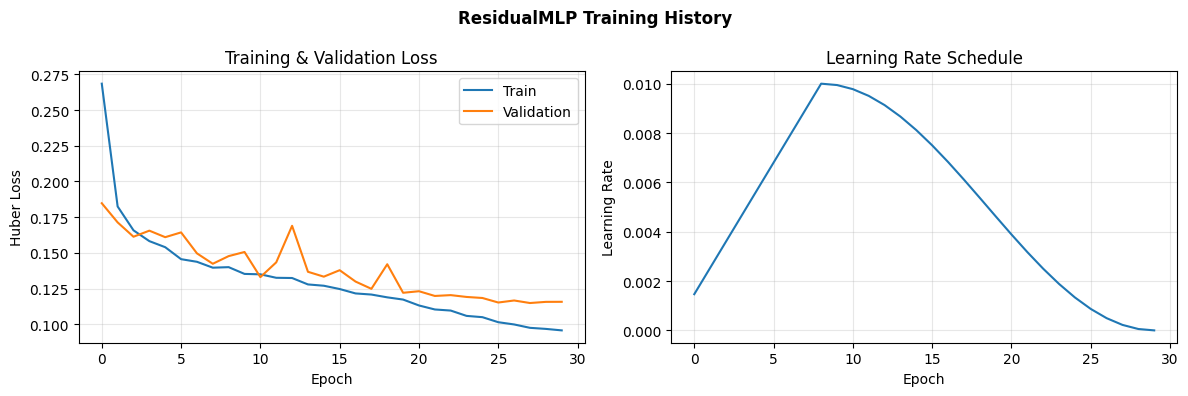

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate
axes[1].plot(history['lr'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResidualMLP Training History', fontweight='bold')
plt.tight_layout()
plt.show()

---

# Section 8: Custom Optimizer

## Concept

Custom optimizers in PyTorch extend `torch.optim.Optimizer`. We'll implement:

1. **SGD with Momentum** - From scratch
2. **AdamW** - Adam with decoupled weight decay

---

In [ ]:
class CustomSGD(optim.Optimizer):
    """
    Custom SGD with Momentum from scratch.

    Update rule:
    v = momentum * v + gradient
    w = w - lr * v

    Args:
        params: Model parameters
        lr: Learning rate
        momentum: Momentum factor
        weight_decay: L2 regularization
    """

    def __init__(self, params, lr=0.01, momentum=0.9, weight_decay=0):
        if lr < 0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if momentum < 0:
            raise ValueError(f"Invalid momentum: {momentum}")

        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay)
        super(CustomSGD, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        """
        Perform a single optimization step.

        Args:
            closure: A closure that reevaluates the model and returns the loss
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            weight_decay = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue

                # Get gradient
                d_p = p.grad

                # Apply weight decay (L2 regularization)
                if weight_decay != 0:
                    d_p = d_p + weight_decay * p

                # Apply momentum
                if momentum != 0:
                    # Get or create velocity buffer
                    param_state = self.state[p]
                    if 'velocity' not in param_state:
                        param_state['velocity'] = torch.zeros_like(p)

                    v = param_state['velocity']
                    v.mul_(momentum).add_(d_p)
                    d_p = v

                # Update parameters
                p.add_(d_p, alpha=-lr)

        return loss


class CustomAdamW(optim.Optimizer):
    """
    Custom AdamW optimizer.

    Adam with decoupled weight decay regularization.

    Args:
        params: Model parameters
        lr: Learning rate
        betas: Coefficients for computing running averages
        eps: Small constant for numerical stability
        weight_decay: Decoupled weight decay
    """

    def __init__(self, params, lr=0.001, betas=(0.9, 0.999),
                 eps=1e-8, weight_decay=0.01):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super(CustomAdamW, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            beta1, beta2 = group['betas']
            eps = group['eps']
            weight_decay = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad

                # Get state
                state = self.state[p]

                # Initialize state
                if len(state) == 0:
                    state['step'] = 0
                    state['m'] = torch.zeros_like(p)  # First moment
                    state['v'] = torch.zeros_like(p)  # Second moment

                m, v = state['m'], state['v']
                state['step'] += 1

                # Update biased first moment estimate
                m.mul_(beta1).add_(grad, alpha=1 - beta1)

                # Update biased second moment estimate
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                # Bias correction
                m_hat = m / (1 - beta1 ** state['step'])
                v_hat = v / (1 - beta2 ** state['step'])

                # Update parameters
                p.addcdiv_(m_hat, v_hat.sqrt() + eps, value=-lr)

                # Decoupled weight decay
                if weight_decay != 0:
                    p.add_(p, alpha=-lr * weight_decay)

        return loss


# Test custom optimizers
print("Custom Optimizers Test")
print("=" * 50)

# Simple test model
test_model = nn.Sequential(
    nn.Linear(8, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

# Test CustomSGD
optimizer_sgd = CustomSGD(test_model.parameters(), lr=0.01, momentum=0.9)
print("CustomSGD created successfully!")

# Quick training step
X_sample = X_train_h_t[:32].to(device)
y_sample = y_train_h_t[:32].to(device)

output = test_model(X_sample)
loss = F.mse_loss(output, y_sample)
loss.backward()
optimizer_sgd.step()
print(f"Training step with CustomSGD - Loss: {loss.item():.4f}")

# Test CustomAdamW
test_model2 = nn.Sequential(
    nn.Linear(8, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

optimizer_adam = CustomAdamW(test_model2.parameters(), lr=0.001, weight_decay=0.01)
print("\nCustomAdamW created successfully!")

output = test_model2(X_sample)
loss = F.mse_loss(output, y_sample)
loss.backward()
optimizer_adam.step()
print(f"Training step with CustomAdamW - Loss: {loss.item():.4f}")

Custom Optimizers Test
CustomSGD created successfully!
Training step with CustomSGD - Loss: 6.5030

CustomAdamW created successfully!
Training step with CustomAdamW - Loss: 5.1660


---

# Section 9: TensorBoard Integration

## Concept

PyTorch integrates with TensorBoard via `torch.utils.tensorboard`. We can log:
- Scalars (loss, accuracy, learning rate)
- Histograms (weight distributions)
- Graphs (model architecture)
- Images, text, and more

---

In [ ]:
# Load TensorBoard extension
%load_ext tensorboard

# Create log directory
import datetime
log_dir = f"runs/pytorch_demo_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)

print(f"TensorBoard logs will be saved to: {log_dir}")

TensorBoard logs will be saved to: runs/pytorch_demo_20260316_034534


### Training with TensorBoard Logging

Let's train a model while logging various metrics to TensorBoard.

In [ ]:
def train_with_tensorboard(model, train_loader, val_loader, criterion,
                           optimizer, writer, epochs=20, device='cpu'):
    """
    Training loop with TensorBoard logging.
    """
    model = model.to(device)
    global_step = 0

    # Log model graph
    sample_input = next(iter(train_loader))[0][:1].to(device)
    writer.add_graph(model, sample_input)

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0

        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

            # Log batch loss
            if batch_idx % 50 == 0:
                writer.add_scalar('Loss/train_batch', loss.item(), global_step)
            global_step += 1

        # Validation
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item() * X_batch.size(0)

        # Calculate epoch metrics
        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)

        # Log epoch metrics
        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/validation', val_loss, epoch)
        writer.add_scalar('LR', optimizer.param_groups[0]['lr'], epoch)

        # Log weight histograms
        for name, param in model.named_parameters():
            writer.add_histogram(f'Weights/{name}', param, epoch)
            if param.grad is not None:
                writer.add_histogram(f'Gradients/{name}', param.grad, epoch)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.4f}, Val: {val_loss:.4f}")

    writer.close()
    return model


# Train with TensorBoard
print("Training with TensorBoard Logging")
print("=" * 50)

tb_model = ResidualMLP(input_dim=8, hidden_dim=64, output_dim=1, n_blocks=2)
tb_optimizer = optim.Adam(tb_model.parameters(), lr=0.001)
tb_criterion = HuberLoss(delta=1.0)

tb_model = train_with_tensorboard(
    tb_model, train_housing_loader, val_housing_loader,
    tb_criterion, tb_optimizer, writer, epochs=20, device=device
)

print(f"\nTensorBoard logs saved. Run: tensorboard --logdir {log_dir}")

Training with TensorBoard Logging
Epoch 5/20 - Train: 0.1380, Val: 0.1427
Epoch 10/20 - Train: 0.1265, Val: 0.1342
Epoch 15/20 - Train: 0.1192, Val: 0.1253
Epoch 20/20 - Train: 0.1146, Val: 0.1295

TensorBoard logs saved. Run: tensorboard --logdir runs/pytorch_demo_20260316_034534


---

# Section 10: Complete Custom Model

Let's put everything together in a final model that combines multiple custom components for Fashion-MNIST classification.

---

In [ ]:
class FullCustomClassifier(nn.Module):
    """
    Complete custom model combining:
    - Custom layers (Linear, LayerNorm, GaussianNoise)
    - Custom activations (Swish)
    - Residual connections
    - MC Dropout for uncertainty
    - Squeeze-Excitation attention
    """

    def __init__(self, input_dim=784, hidden_dim=256, num_classes=10, dropout=0.2):
        super(FullCustomClassifier, self).__init__()

        # Input block
        self.input_block = nn.Sequential(
            CustomLinear(input_dim, hidden_dim),
            CustomLayerNorm(hidden_dim),
            Swish(),
            GaussianNoise(std=0.05)
        )

        # Residual blocks with attention
        self.res_block1 = self._make_res_block(hidden_dim, dropout)
        self.attention1 = SqueezeExcitation(hidden_dim, reduction=8)

        self.res_block2 = self._make_res_block(hidden_dim, dropout)
        self.attention2 = SqueezeExcitation(hidden_dim, reduction=8)

        # Output block
        self.output = nn.Sequential(
            CustomLayerNorm(hidden_dim),
            MCDropout(p=dropout),
            nn.Linear(hidden_dim, num_classes)
        )

        # Initialize weights
        self.apply(self._init_weights)

    def _make_res_block(self, dim, dropout):
        return nn.Sequential(
            CustomLinear(dim, dim),
            CustomLayerNorm(dim),
            Swish(),
            nn.Dropout(dropout),
            CustomLinear(dim, dim),
            CustomLayerNorm(dim)
        )

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, CustomLinear)):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x):
        # Input
        x = self.input_block(x)

        # Residual block 1 with attention
        residual = x
        x = self.res_block1(x)
        x = self.attention1(x)
        x = F.gelu(x + residual)

        # Residual block 2 with attention
        residual = x
        x = self.res_block2(x)
        x = self.attention2(x)
        x = F.gelu(x + residual)

        # Output
        return self.output(x)

    def predict_with_uncertainty(self, x, n_samples=50):
        """
        Make predictions with uncertainty estimation using MC Dropout.

        Args:
            x: Input tensor
            n_samples: Number of forward passes

        Returns:
            mean_probs: Mean predicted probabilities
            std_probs: Standard deviation (uncertainty)
        """
        self.train()  # Keep dropout active

        predictions = []
        with torch.no_grad():
            for _ in range(n_samples):
                logits = self(x)
                probs = F.softmax(logits, dim=1)
                predictions.append(probs)

        predictions = torch.stack(predictions)
        mean_probs = predictions.mean(dim=0)
        std_probs = predictions.std(dim=0)

        return mean_probs, std_probs


# Train the full custom model
print("Training Full Custom Classifier on Fashion-MNIST")
print("=" * 50)

full_model = FullCustomClassifier(
    input_dim=784, hidden_dim=256, num_classes=10, dropout=0.2
).to(device)

print(f"Model parameters: {sum(p.numel() for p in full_model.parameters()):,}")

# Use custom components
criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer = CustomAdamW(full_model.parameters(), lr=0.001, weight_decay=0.01)

# Training loop
epochs = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    # Training
    full_model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_fashion_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = full_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    # Validation
    full_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_fashion_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = full_model(X_batch)
            val_loss += F.cross_entropy(outputs, y_batch).item() * X_batch.size(0)

            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()

    train_loss /= len(train_fashion_loader.dataset)
    val_loss /= len(val_fashion_loader.dataset)
    val_acc = correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Training Full Custom Classifier on Fashion-MNIST
Model parameters: 502,538
Epoch 3/15 - Train Loss: 0.8680, Val Loss: 0.4751, Val Acc: 0.8637
Epoch 6/15 - Train Loss: 0.7990, Val Loss: 0.4199, Val Acc: 0.8811
Epoch 9/15 - Train Loss: 0.7656, Val Loss: 0.4004, Val Acc: 0.8838
Epoch 12/15 - Train Loss: 0.7438, Val Loss: 0.3912, Val Acc: 0.8856
Epoch 15/15 - Train Loss: 0.7241, Val Loss: 0.3775, Val Acc: 0.8944


### Evaluate with Uncertainty Estimation

Let's use MC Dropout to get uncertainty estimates for our predictions.

In [ ]:
# Evaluate on test set with uncertainty
print("\nEvaluating with Uncertainty Estimation")
print("=" * 50)

# Standard evaluation
full_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_fashion_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = full_model(X_batch)
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

test_acc = correct / total
print(f"Test Accuracy (standard): {test_acc:.4f}")

# MC Dropout evaluation on subset
X_sample, y_sample = next(iter(test_fashion_loader))
X_sample, y_sample = X_sample.to(device), y_sample.to(device)

mean_probs, std_probs = full_model.predict_with_uncertainty(X_sample, n_samples=50)
mc_predictions = mean_probs.argmax(dim=1)
mc_accuracy = (mc_predictions == y_sample).float().mean().item()

print(f"MC Dropout Accuracy (batch): {mc_accuracy:.4f}")

# Analyze uncertainty
uncertainties = std_probs.mean(dim=1)  # Average uncertainty per sample
correct_mask = mc_predictions == y_sample

print(f"\nUncertainty Analysis:")
print(f"  Avg uncertainty (correct):   {uncertainties[correct_mask].mean():.4f}")
print(f"  Avg uncertainty (incorrect): {uncertainties[~correct_mask].mean():.4f}")
print("  -> Higher uncertainty for incorrect predictions!")


Evaluating with Uncertainty Estimation
Test Accuracy (standard): 0.8895
MC Dropout Accuracy (batch): 0.8906

Uncertainty Analysis:
  Avg uncertainty (correct):   0.0107
  Avg uncertainty (incorrect): 0.0196
  -> Higher uncertainty for incorrect predictions!


### Visualize Training and Uncertainty

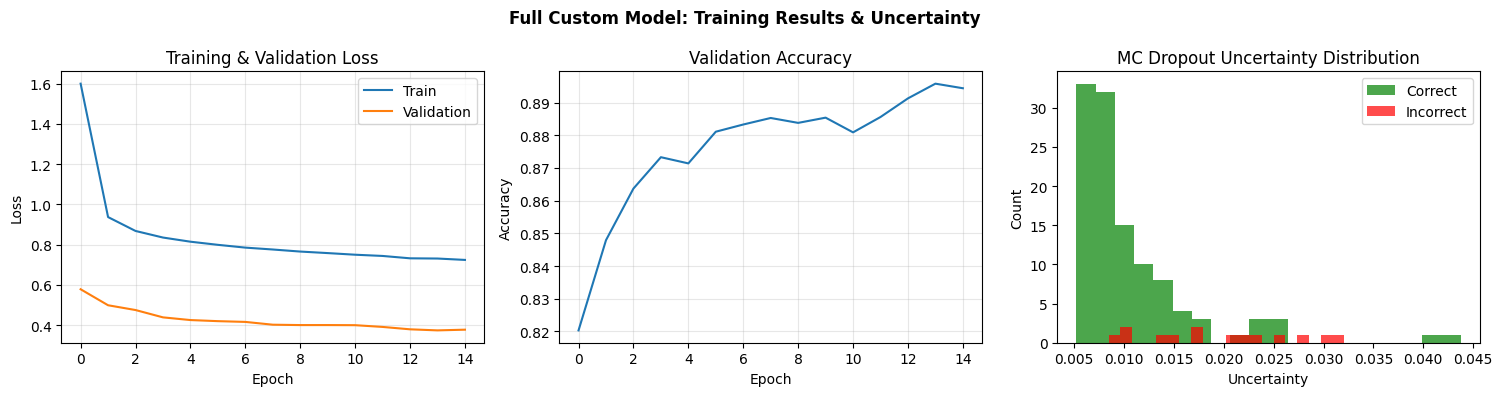

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['val_acc'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].grid(True, alpha=0.3)

# Uncertainty distribution
axes[2].hist(uncertainties[correct_mask].cpu().numpy(), bins=20, alpha=0.7, label='Correct', color='green')
axes[2].hist(uncertainties[~correct_mask].cpu().numpy(), bins=20, alpha=0.7, label='Incorrect', color='red')
axes[2].set_xlabel('Uncertainty')
axes[2].set_ylabel('Count')
axes[2].set_title('MC Dropout Uncertainty Distribution')
axes[2].legend()

plt.suptitle('Full Custom Model: Training Results & Uncertainty', fontweight='bold')
plt.tight_layout()
plt.show()

---

# Summary

In this notebook, we implemented the following custom PyTorch components:

| Component | Implementation | Key Features |
|-----------|---------------|---------------|
| **LR Schedulers** | OneCycleLR, WarmupCosine | Super-convergence, warmup |
| **Dropout** | MCDropout, AlphaDropout | Uncertainty estimation, SELU-compatible |
| **Loss Functions** | HuberLoss, FocalLoss, LabelSmoothing | Robust, imbalanced data, regularization |
| **Activations** | Swish, Mish, GELU, ParametricReLU | Modern smooth activations |
| **Initialization** | Xavier, Kaiming, Orthogonal | Proper weight init |
| **Layers** | CustomLinear, LayerNorm, GaussianNoise, SE | Building blocks |
| **Models** | ResidualMLP, AttentionMLP | Complete architectures |
| **Optimizers** | CustomSGD, CustomAdamW | Momentum, decoupled weight decay |
| **TensorBoard** | Scalars, histograms, graphs | Training visualization |

---

In [ ]:
print("\n" + "="*70)
print("NOTEBOOK 4: ADVANCED PYTORCH CUSTOMIZATIONS - COMPLETE")
print("="*70)
print("""
This notebook demonstrated how to build neural network components
from scratch in PyTorch. Key takeaways:

1. PyTorch's nn.Module provides a flexible base for custom components
2. The forward() method defines the computation
3. Parameters are automatically tracked when using nn.Parameter
4. Custom optimizers extend torch.optim.Optimizer
5. LR schedulers extend torch.optim.lr_scheduler._LRScheduler
6. MC Dropout enables uncertainty estimation
7. TensorBoard integration helps monitor training

Comparison with Keras:
- PyTorch: More explicit, Pythonic, dynamic graphs
- Keras: Higher-level API, easier for beginners
- Both: Powerful for building custom components
""")
print("="*70)


NOTEBOOK 4: ADVANCED PYTORCH CUSTOMIZATIONS - COMPLETE

This notebook demonstrated how to build neural network components
from scratch in PyTorch. Key takeaways:

1. PyTorch's nn.Module provides a flexible base for custom components
2. The forward() method defines the computation
3. Parameters are automatically tracked when using nn.Parameter
4. Custom optimizers extend torch.optim.Optimizer
5. LR schedulers extend torch.optim.lr_scheduler._LRScheduler
6. MC Dropout enables uncertainty estimation
7. TensorBoard integration helps monitor training

Comparison with Keras:
- PyTorch: More explicit, Pythonic, dynamic graphs
- Keras: Higher-level API, easier for beginners
- Both: Powerful for building custom components

